# Binance BTC 1-second historical klines

Pulls **1-second OHLCV candles** for BTC from Binance and lands them in a tidy `pandas` DataFrame / Parquet file.

**No API key is needed.** Binance market data (klines, trades, order book snapshots) is a public endpoint —
keys are only required for account/trading endpoints. Nothing here touches your account.

### Two data sources, used together

| Source | Covers | Speed |
|---|---|---|
| **`data.binance.vision`** — free bulk ZIP archives | Everything up to ~1 day ago. 1s klines exist back to **Aug 2017**. | ~2.6M rows per monthly file, one HTTP request |
| **REST `/api/v3/klines`** | The last day or two the archives haven't published yet | 1000 candles per request (= 16.6 min of 1s data) |

`get_klines()` below stitches them together automatically: archives for bulk history,
REST for the recent tail, deduped and sorted.

### A note on "USD"
Binance.com's BTC/USD pair is really **`BTCUSDT`** (Tether) — that's the deepest book and the one with
full 1s history. Alternatives if you want them: `BTCUSDC`, `BTCFDUSD`. A true USD pair (`BTCUSD`) only
exists on Binance.US, which is a separate venue with much thinner liquidity and a different archive host.
Set `SYMBOL` below.

## 1. Config

In [1]:
from __future__ import annotations

import concurrent.futures as cf
import hashlib
import io
import time
import zipfile
from datetime import date, datetime, timedelta, timezone
from pathlib import Path

import pandas as pd
import requests

SYMBOL   = "BTCUSDT"      # BTCUSDC / BTCFDUSD also have 1s history
INTERVAL = "1s"

# UTC date range, inclusive of START, exclusive of END.
# Default: the last 3 days, which exercises both the archive and the REST tail.
END   = datetime.now(timezone.utc).replace(minute=0, second=0, microsecond=0)
START = END - timedelta(days=3)

DATA_DIR   = Path("data")
RAW_DIR    = DATA_DIR / "raw"          # cached .zip archives, safe to delete
OUT_DIR    = DATA_DIR / "parquet"
VERIFY_SHA = True                       # check .CHECKSUM for each archive
MAX_DL_WORKERS = 4

for d in (RAW_DIR, OUT_DIR):
    d.mkdir(parents=True, exist_ok=True)

VISION_BASE = "https://data.binance.vision/data/spot"
API_BASE    = "https://api.binance.com"

SESSION = requests.Session()
SESSION.headers["User-Agent"] = "binance-1s-notebook/1.0"

COLUMNS = [
    "open_time", "open", "high", "low", "close", "volume", "close_time",
    "quote_volume", "trades", "taker_buy_base", "taker_buy_quote", "ignore",
]

print(f"{SYMBOL} {INTERVAL}  {START:%Y-%m-%d %H:%M} -> {END:%Y-%m-%d %H:%M} UTC")

BTCUSDT 1s  2026-09-07 04:00 -> 2026-09-10 04:00 UTC


## 2. Bulk archives (`data.binance.vision`)

Files are cached under `data/raw/`, so re-running a range costs nothing. Layout:

```
/data/spot/daily/klines/BTCUSDT/1s/BTCUSDT-1s-2026-09-07.zip
/data/spot/monthly/klines/BTCUSDT/1s/BTCUSDT-1s-2026-08.zip
```

One wrinkle worth knowing: Binance switched the archive timestamp unit from **milliseconds to
microseconds in Jan 2025**, and some vintages ship a CSV header row while others don't. The reader
below sniffs both.

In [2]:
def _archive_url(symbol: str, interval: str, stamp: str, monthly: bool) -> str:
    kind = "monthly" if monthly else "daily"
    return f"{VISION_BASE}/{kind}/klines/{symbol}/{interval}/{symbol}-{interval}-{stamp}.zip"


def download_archive(symbol: str, interval: str, stamp: str, monthly: bool) -> Path | None:
    """Fetch one archive into the cache. Returns None if Binance has no such file (404)."""
    url = _archive_url(symbol, interval, stamp, monthly)
    dest = RAW_DIR / Path(url).name
    if dest.exists() and dest.stat().st_size > 0:
        return dest

    r = SESSION.get(url, timeout=120, stream=True)
    if r.status_code == 404:
        return None
    r.raise_for_status()

    tmp = dest.with_suffix(".part")
    sha = hashlib.sha256()
    with tmp.open("wb") as fh:
        for chunk in r.iter_content(1 << 20):
            fh.write(chunk)
            sha.update(chunk)

    if VERIFY_SHA:
        c = SESSION.get(url + ".CHECKSUM", timeout=30)
        if c.ok:
            expected = c.text.split()[0]
            if expected != sha.hexdigest():
                tmp.unlink(missing_ok=True)
                raise ValueError(f"checksum mismatch for {dest.name}")

    tmp.rename(dest)
    return dest


def read_archive(path: Path) -> pd.DataFrame:
    """Parse a klines ZIP into a DataFrame, normalising the timestamp unit."""
    with zipfile.ZipFile(path) as z:
        raw = z.read(z.namelist()[0])

    first = raw.split(b"\n", 1)[0]
    has_header = not first.split(b",")[0].strip().isdigit()

    df = pd.read_csv(
        io.BytesIO(raw),
        header=0 if has_header else None,
        names=COLUMNS,
        dtype={c: "float64" for c in
               ("open", "high", "low", "close", "volume",
                "quote_volume", "taker_buy_base", "taker_buy_quote")},
    )
    return _normalise(df)


def _normalise(df: pd.DataFrame) -> pd.DataFrame:
    """Coerce open/close_time to int64 milliseconds and drop the padding column."""
    for col in ("open_time", "close_time"):
        t = df[col].astype("int64")
        # >1e15 means microseconds (post-2025 archives); REST always returns ms.
        df[col] = (t // 1000).where(t > 10**15, t)
    df["trades"] = df["trades"].astype("int64")
    return df.drop(columns=["ignore"])

## 3. REST tail

Archives publish roughly a day in arrears, so anything newer comes from `/api/v3/klines`.
At `1s` that's 1000 candles (16m 40s) per call, so this is strictly for the tail — don't try to
pull a year through it. The loop watches the `x-mbx-used-weight-1m` header and backs off on 429.

In [3]:
INTERVAL_MS = {"1s": 1_000, "1m": 60_000, "1h": 3_600_000, "1d": 86_400_000}


def fetch_api_klines(symbol: str, start_ms: int, end_ms: int, interval: str = INTERVAL) -> pd.DataFrame:
    """Page /api/v3/klines over [start_ms, end_ms). Public endpoint, no key."""
    step = INTERVAL_MS[interval]
    rows: list[list] = []
    cursor = start_ms

    while cursor < end_ms:
        resp = SESSION.get(
            f"{API_BASE}/api/v3/klines",
            params={"symbol": symbol, "interval": interval, "startTime": cursor,
                    "endTime": end_ms - 1, "limit": 1000},
            timeout=30,
        )
        if resp.status_code in (418, 429):
            time.sleep(int(resp.headers.get("Retry-After", 10)))
            continue
        resp.raise_for_status()

        batch = resp.json()
        if not batch:
            break
        rows.extend(batch)
        cursor = batch[-1][0] + step

        used = int(resp.headers.get("x-mbx-used-weight-1m", 0))
        if used > 4000:          # limit is 6000/min; leave headroom
            time.sleep(10)

    if not rows:
        return pd.DataFrame(columns=[c for c in COLUMNS if c != "ignore"])
    return _normalise(pd.DataFrame(rows, columns=COLUMNS).astype(
        {c: "float64" for c in ("open", "high", "low", "close", "volume",
                                "quote_volume", "taker_buy_base", "taker_buy_quote")}))

## 4. `get_klines()` — the one function you call

Greedily uses a monthly archive whenever a whole calendar month falls inside the range, daily
archives for the ragged edges, and the REST API for any day the archive doesn't have yet.
Downloads run 4-wide; the result is deduped on `open_time` and clipped to the exact range.

In [4]:
def _plan(start: datetime, end: datetime) -> list[tuple[str, bool]]:
    """Split [start, end) into (stamp, is_monthly) archive chunks."""
    chunks, cur, last = [], start.date(), (end - timedelta(milliseconds=1)).date()
    while cur <= last:
        nxt_month = (cur.replace(day=1) + timedelta(days=32)).replace(day=1)
        whole_month_inside = cur.day == 1 and nxt_month <= last + timedelta(days=1)
        if whole_month_inside:
            chunks.append((cur.strftime("%Y-%m"), True))
            cur = nxt_month
        else:
            chunks.append((cur.strftime("%Y-%m-%d"), False))
            cur += timedelta(days=1)
    return chunks


def _load_chunk(symbol: str, interval: str, stamp: str, monthly: bool) -> pd.DataFrame:
    path = download_archive(symbol, interval, stamp, monthly)
    if path is not None:
        return read_archive(path)

    # No archive yet (recent days) -> REST fallback for that window.
    if monthly:
        d0 = datetime.strptime(stamp, "%Y-%m").replace(tzinfo=timezone.utc)
        d1 = (d0 + timedelta(days=32)).replace(day=1)
    else:
        d0 = datetime.strptime(stamp, "%Y-%m-%d").replace(tzinfo=timezone.utc)
        d1 = d0 + timedelta(days=1)
    now_ms = int(time.time() * 1000)
    return fetch_api_klines(symbol, int(d0.timestamp() * 1000),
                            min(int(d1.timestamp() * 1000), now_ms), interval)


def get_klines(symbol: str = SYMBOL, start: datetime = START, end: datetime = END,
               interval: str = INTERVAL, verbose: bool = True) -> pd.DataFrame:
    plan = _plan(start, end)
    if verbose:
        print(f"{len(plan)} chunk(s): " + ", ".join(s for s, _ in plan[:8]) +
              (" ..." if len(plan) > 8 else ""))

    with cf.ThreadPoolExecutor(MAX_DL_WORKERS) as pool:
        frames = list(pool.map(lambda c: _load_chunk(symbol, interval, *c), plan))

    df = pd.concat([f for f in frames if len(f)], ignore_index=True)
    lo, hi = int(start.timestamp() * 1000), int(end.timestamp() * 1000)
    df = df[(df.open_time >= lo) & (df.open_time < hi)]
    df = df.drop_duplicates("open_time").sort_values("open_time", ignore_index=True)

    df.insert(0, "ts", pd.to_datetime(df.open_time, unit="ms", utc=True))
    return df.set_index("ts")

## 5. Run it

In [5]:
df = get_klines()

print(f"\n{len(df):,} rows   {df.index[0]}  ->  {df.index[-1]}")
df.head()

4 chunk(s): 2026-09-07, 2026-09-08, 2026-09-09, 2026-09-10



259,200 rows   2026-09-07 04:00:00+00:00  ->  2026-09-10 03:59:59+00:00


,open_time,open,high,low,close,volume,close_time,quote_volume,trades,taker_buy_base,taker_buy_quote
ts,,,,,,,,,,,
2026-09-07 04:00:00+00:00,1788753600000,79596.38,79596.39,79596.38,79596.39,0.01864,1788753600999,1483.676571,23,0.00476,378.878816
2026-09-07 04:00:01+00:00,1788753601000,79596.39,79596.39,79596.38,79596.38,0.00721,1788753601999,573.889941,13,0.00411,327.141163
2026-09-07 04:00:02+00:00,1788753602000,79596.39,79596.39,79596.38,79596.39,0.15174,1788753602999,12077.955228,44,0.05268,4193.137825
2026-09-07 04:00:03+00:00,1788753603000,79596.39,79596.39,79596.38,79596.39,0.01246,1788753603999,991.770987,16,0.00926,737.062571
2026-09-07 04:00:04+00:00,1788753604000,79596.38,79596.39,79596.38,79596.39,0.01614,1788753604999,1284.685695,18,0.01222,972.667886


In [6]:
df[["open", "high", "low", "close", "volume", "trades"]].describe().T

,count,mean,std,min,25%,50%,75%,max
open,259200.0,78866.969561,462.755313,77626.68,78489.65000,78830.01000,79233.99000,79926.04000
high,259200.0,78867.460549,462.655532,77653.28,78490.00000,78830.43000,79234.00000,79926.04000
low,259200.0,78866.459583,462.869087,77620.01,78488.54750,78830.00000,79233.41000,79926.03000
close,259200.0,78866.964049,462.754371,77626.68,78489.65000,78830.01000,79233.99000,79926.04000
volume,259200.0,0.170046,0.979213,0.00,0.00129,0.01379,0.07687,111.79648
trades,259200.0,38.958804,94.540167,0.00,2.00000,5.00000,23.00000,4763.00000


## 6. Gap check

Binance omits seconds in which no trade printed, so a raw pull is *not* a contiguous 1Hz series.
Check how much is missing, then decide whether you want it reindexed.

In [7]:
expected = int((df.open_time.iloc[-1] - df.open_time.iloc[0]) / 1000) + 1
missing  = expected - len(df)
print(f"expected {expected:,} seconds, have {len(df):,}  ->  {missing:,} missing ({missing/expected:.3%})")

gaps = df.open_time.diff().div(1000).sub(1)
worst = gaps[gaps > 0].sort_values(ascending=False).head(10)
print("\nlargest gaps (seconds skipped):")
print(worst if len(worst) else "  none")

expected 259,200 seconds, have 259,200  ->  0 missing (0.000%)

largest gaps (seconds skipped):
  none


In [8]:
def to_regular_1s(df: pd.DataFrame) -> pd.DataFrame:
    """Reindex onto a strict 1-second grid: carry the last close, zero the flow columns."""
    grid = pd.date_range(df.index[0], df.index[-1], freq="1s", tz="UTC", name="ts")
    out  = df.reindex(grid)
    out["close"] = out["close"].ffill()
    for c in ("open", "high", "low"):
        out[c] = out[c].fillna(out["close"])
    for c in ("volume", "quote_volume", "trades", "taker_buy_base", "taker_buy_quote"):
        out[c] = out[c].fillna(0)
    out["open_time"] = (out.index.view("int64") // 10**6)
    out["close_time"] = out["open_time"] + 999
    return out


regular = to_regular_1s(df)
print(f"{len(regular):,} rows on a strict 1s grid, no NaNs: {not regular['close'].isna().any()}")
regular.head(3)

259,200 rows on a strict 1s grid, no NaNs: True


,open_time,open,high,low,close,volume,close_time,quote_volume,trades,taker_buy_base,taker_buy_quote
ts,,,,,,,,,,,
2026-09-07 04:00:00+00:00,1788753,79596.38,79596.39,79596.38,79596.39,0.01864,1789752,1483.676571,23,0.00476,378.878816
2026-09-07 04:00:01+00:00,1788753,79596.39,79596.39,79596.38,79596.38,0.00721,1789752,573.889941,13,0.00411,327.141163
2026-09-07 04:00:02+00:00,1788753,79596.39,79596.39,79596.38,79596.39,0.15174,1789752,12077.955228,44,0.05268,4193.137825


## 7. Save

In [9]:
out = OUT_DIR / f"{SYMBOL}_{INTERVAL}_{START:%Y%m%dT%H%M}_{END:%Y%m%dT%H%M}.parquet"
df.to_parquet(out, compression="zstd")
print(f"{out}  ({out.stat().st_size/1e6:.1f} MB for {len(df):,} rows)")

# read back with:  pd.read_parquet(out)

data/parquet/BTCUSDT_1s_20260907T0400_20260910T0400.parquet  (9.4 MB for 259,200 rows)


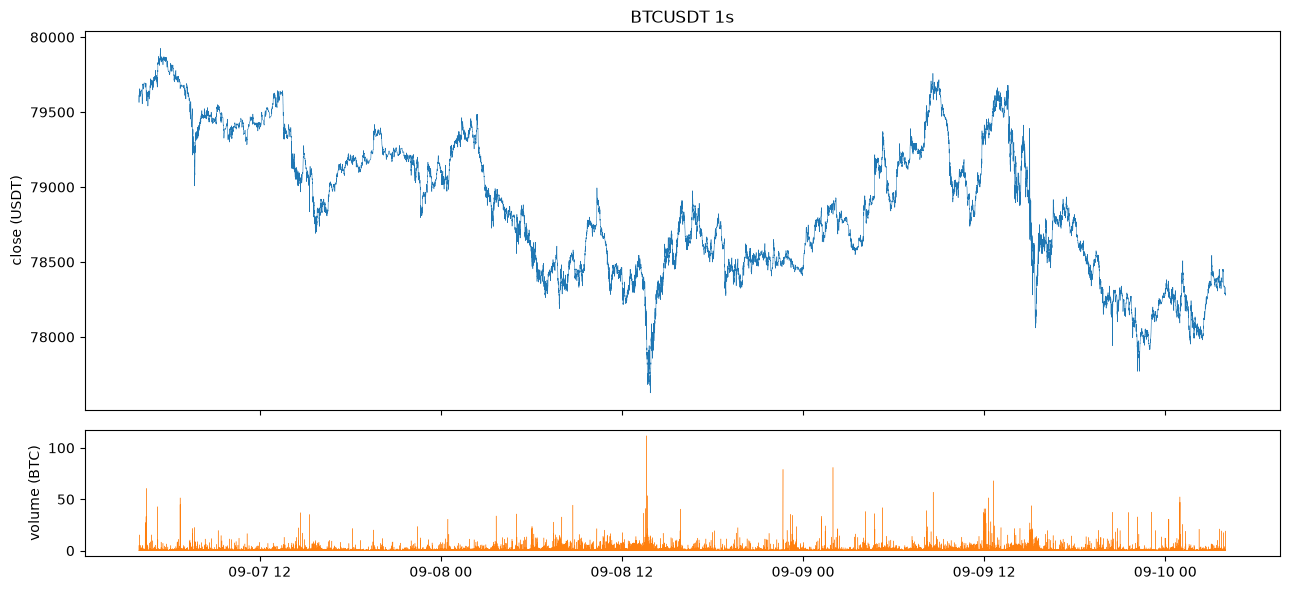

In [10]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(df.index, df.close, lw=0.4)
ax1.set_ylabel("close (USDT)")
ax1.set_title(f"{SYMBOL} {INTERVAL}")
ax2.plot(df.index, df.volume, lw=0.3, color="tab:orange")
ax2.set_ylabel("volume (BTC)")
fig.tight_layout()
plt.show()

## Notes for going bigger

**Sizing.** 1s BTCUSDT is ~2.6M rows/month, ~86MB zipped per monthly archive. A full year is
~31M rows — around 400–600MB as zstd Parquet, and it will not fit comfortably in RAM as one
DataFrame alongside anything else. For multi-year pulls, loop month by month and write one
Parquet file per month:

```python
for m in pd.date_range("2024-01-01", "2025-01-01", freq="MS", tz="UTC")[:-1]:
    nxt = m + pd.offsets.MonthBegin(1)
    part = get_klines(start=m.to_pydatetime(), end=nxt.to_pydatetime(), verbose=False)
    part.to_parquet(OUT_DIR / f"{SYMBOL}_1s_{m:%Y%m}.parquet", compression="zstd")
```

then read the directory lazily with `pyarrow.dataset`, `duckdb`, or `polars.scan_parquet`.

**History depth.** 1s klines go back to **2017-08** for BTCUSDT. Early years are sparse — many
seconds simply had no trades.

**Rate limits.** The archive host is unmetered. The REST endpoint allows 6000 weight/minute per IP;
`fetch_api_klines` reads the used-weight header and backs off, but keep `MAX_DL_WORKERS` modest
and don't fan REST calls out in parallel.

**Cache.** `data/raw/` holds the downloaded ZIPs — deleting it only costs you a re-download.

**Other data types.** Same code shape works for `aggTrades`, `trades`, and `bookTicker` by swapping
`klines` in the archive path; for tick-level work `aggTrades` is usually what you want instead of 1s bars.

**If you ever do need a key** (trading, account endpoints): binance.com → API Management → create key,
then keep it in an env var, never in this notebook.